## Comparación de Técnicas de Tokenización para Series Temporales

### Objetivo

Comparar las 6 técnicas de tokenización identificadas en el Anteproyecto-RITMO sobre el dataset Electricity.

#### Técnicas Comparadas

| Técnica | Paper Original | Tipo |
|---------|---------------|------|
| **HMM (Viterbi)** | Tesis RITMO (2025) | Estados ocultos de Markov |
| **SAX** | Lin et al. (2007) | Discretización gaussiana |
| **LLMTime** | Gruver et al. (2023) | Conversión a texto |
| **PatchTST** | Nie et al. (2023) | Segmentación en patches |
| **Autoformer** | Wu et al. (2021) | Descomposición trend-seasonal |
| **MOMENT** | Goswami et al. (2024) | Masked patches pre-training |

#### Dataset

**Electricity**: Consumo eléctrico MT_320 (26,304 timesteps, 321 variables univariadas)

Cache HMM pre-computado disponible con K ∈ {3, 4, 5, 6, 7, 8, 9} estados.

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
import sys
from scipy import stats

# Añadir path del proyecto
sys.path.append('/home/jaime/TFG/RITMO')

# Imports de técnicas de tokenización
from tecnicas import (
    sax_discretize, visualize_sax,
    text_based_tokenize, visualize_text_based,
    patching_tokenize, visualize_patches,
    decomposition_tokenize, visualize_decomposition,
    foundation_tokenize, visualize_foundation
)

# ========== CONFIGURACIÓN MATPLOTLIB ==========
# Tipografía paper-friendly
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Tamaños de fuente (IEEE/Nature standard)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 12

# Líneas y grids
plt.rcParams['lines.linewidth'] = 1.0
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.3

# Estilo seaborn
sns.set_style('whitegrid')

# Paleta colorblind-friendly (Okabe-Ito recomendada por Nature)
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
sns.set_palette(okabe_ito)

# Tamaños de figura estándar IEEE Transactions
FIGSIZE_SINGLE = (3.5, 2.625)    # Single column (aspect 4:3)
FIGSIZE_DOUBLE = (7.16, 5.37)    # Double column (aspect 4:3)

# Función savefig mejorada (PDF vectorial + PNG raster)
def savefig(ax_or_fig, fname: str, dpi: int = 300, vector: bool = True):
    """Guarda figura en formato optimizado para publicación."""
    import os
    dirpath = Path.cwd() / 'figures'
    dirpath.mkdir(parents=True, exist_ok=True)

    # Guardar en formato vectorial (PDF) para papers
    if vector:
        fullpath_pdf = dirpath / f"{Path(fname).stem}.pdf"
        if hasattr(ax_or_fig, 'savefig'):
            ax_or_fig.savefig(fullpath_pdf, format='pdf', bbox_inches='tight')
        else:
            plt.savefig(fullpath_pdf, format='pdf', bbox_inches='tight')
        print(f'Vector: {fullpath_pdf}')

    # Guardar también en PNG de alta resolución (para presentaciones)
    fullpath_png = dirpath / f"{Path(fname).stem}.png"
    if hasattr(ax_or_fig, 'savefig'):
        ax_or_fig.savefig(fullpath_png, dpi=dpi, bbox_inches='tight')
    else:
        plt.savefig(fullpath_png, dpi=dpi, bbox_inches='tight')
    print(f'Raster: {fullpath_png}')

# Global heatmap vmin/vmax presets (se pueden ajustar por dataset)
GLOBAL_HEAT_VMIN = None
GLOBAL_HEAT_VMAX = None

# Aplicar semilla inicial para reproducibilidad
def set_seed(seed: int = 42):
    import random
    import numpy as _np
    random.seed(seed)
    _np.random.seed(seed)
    try:
        import torch as _torch
        _torch.manual_seed(seed)
        _torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

set_seed(42)

print("[OK] Imports completados")
print(f"Versiones: NumPy {np.__version__}, Pandas {pd.__version__}, Matplotlib {plt.matplotlib.__version__}")
print("Configuración aplicada")
print("  - Paleta: Okabe-Ito (colorblind-friendly)")
print(f"  - Tamaños: Single={FIGSIZE_SINGLE}, Double={FIGSIZE_DOUBLE}")
print("  - Guardado: PDF (vectorial) + PNG (raster)")

[OK] Imports completados
Versiones: NumPy 2.2.6, Pandas 2.3.3, Matplotlib 3.10.8
Configuración aplicada
  - Paleta: Okabe-Ito (colorblind-friendly)
  - Tamaños: Single=(3.5, 2.625), Double=(7.16, 5.37)
  - Guardado: PDF (vectorial) + PNG (raster)


In [2]:
# Cargar cache HMM pre-computado
BASE_DIR = Path('/home/jaime/TFG/RITMO')
DATASET_DIR = BASE_DIR / 'dataset'
CACHE_DIR = BASE_DIR / 'cache'

cache_electricity = pickle.load(open(CACHE_DIR / 'results_electricity.pkl', 'rb'))
cache_etth2 = pickle.load(open(CACHE_DIR / 'results_etth2.pkl', 'rb'))

print("[CACHE HMM]")
print(f"  Electricity: {len(cache_electricity)} configuraciones")
print(f"  ETTh2: {len(cache_etth2)} configuraciones")
print(f"\n[CACHE KEYS] {list(cache_electricity[0].keys())}")

[CACHE HMM]
  Electricity: 42 configuraciones
  ETTh2: 42 configuraciones

[CACHE KEYS] ['K', 'seed', 'data_config', 'train_size', 'revin_success', 'revin_mse', 'hmm_converged', 'hmm_n_iter', 'hmm_checks', 'log_likelihood', 'AIC', 'BIC', 'unique_states', 'n_tokens_llm', 'n_segments', 'compression_ratio', 'avg_segment_duration', 'state_entropy', 'viterbi_checks', 'data_raw', 'data_norm', 'states', 'params']


In [3]:
# Cargar datasets raw (solo para referencia, usaremos datos del cache)
df_electricity = pd.read_csv(DATASET_DIR / 'electricity' / 'electricity.csv')
df_etth2 = pd.read_csv(DATASET_DIR / 'ETT-small' / 'ETTh2.csv')

print("[DATASETS RAW]")
print(f"  Electricity: {df_electricity.shape[0]} timesteps, {df_electricity.shape[1]-1} variables (sin 'date')")
print(f"    - Columnas: {df_electricity.columns.tolist()[:5]} ... (primeras 5)")
print(f"  ETTh2: {df_etth2.shape[0]} timesteps, {df_etth2.shape[1]-1} variables (sin 'date')")
print(f"    - Columnas: {df_etth2.columns.tolist()}")

[DATASETS RAW]
  Electricity: 26304 timesteps, 321 variables (sin 'date')
    - Columnas: ['date', '0', '1', '2', '3'] ... (primeras 5)
  ETTh2: 17420 timesteps, 7 variables (sin 'date')
    - Columnas: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


In [4]:
# Seleccionar K=5 estados para análisis
k_values_elec = sorted(set([entry['K'] for entry in cache_electricity]))
k_values_etth2 = sorted(set([entry['K'] for entry in cache_etth2]))

print("[VALORES K DISPONIBLES]")
print(f"  Electricity: {k_values_elec}")
print(f"  ETTh2: {k_values_etth2}")

K_SELECTED = 5

# Buscar entrada correspondiente a K=5
hmm_elec = [e for e in cache_electricity if e['K'] == K_SELECTED][0]
hmm_etth2 = [e for e in cache_etth2 if e['K'] == K_SELECTED][0]

print(f"\n[CONFIGURACIÓN SELECCIONADA: K={K_SELECTED}]")
print("\nElectricity:")
print(f"  - Convergencia: {hmm_elec['hmm_converged']}")
print(f"  - Iteraciones EM: {hmm_elec['hmm_n_iter']}")
print(f"  - Log-likelihood: {hmm_elec['log_likelihood']:.2f}")
print(f"  - AIC: {hmm_elec['AIC']:.2f}")
print(f"  - BIC: {hmm_elec['BIC']:.2f}")
print(f"  - Compression Ratio: {hmm_elec['compression_ratio']:.2f}")
print(f"  - Entropía Estados: {hmm_elec['state_entropy']:.3f}")

print("\nETTh2:")
print(f"  - Convergencia: {hmm_etth2['hmm_converged']}")
print(f"  - Iteraciones EM: {hmm_etth2['hmm_n_iter']}")
print(f"  - Log-likelihood: {hmm_etth2['log_likelihood']:.2f}")
print(f"  - AIC: {hmm_etth2['AIC']:.2f}")
print(f"  - BIC: {hmm_etth2['BIC']:.2f}")
print(f"  - Compression Ratio: {hmm_etth2['compression_ratio']:.2f}")
print(f"  - Entropía Estados: {hmm_etth2['state_entropy']:.3f}")

[VALORES K DISPONIBLES]
  Electricity: [3, 4, 5, 6, 7, 8, 9]
  ETTh2: [3, 4, 5, 6, 7, 8, 9]

[CONFIGURACIÓN SELECCIONADA: K=5]

Electricity:
  - Convergencia: True
  - Iteraciones EM: 177
  - Log-likelihood: -10461.81
  - AIC: 20993.61
  - BIC: 21267.34
  - Compression Ratio: 6.45
  - Entropía Estados: 1.583

ETTh2:
  - Convergencia: True
  - Iteraciones EM: 53
  - Log-likelihood: -1833.09
  - AIC: 3736.19
  - BIC: 3983.43
  - Compression Ratio: 16.43
  - Entropía Estados: 1.603


In [5]:
# Extraer series normalizadas y estados del cache
elec_data_norm = hmm_elec['data_norm']
elec_states = hmm_elec['states']
elec_params = hmm_elec['params']

etth2_data_norm = hmm_etth2['data_norm']
etth2_states = hmm_etth2['states']
etth2_params = hmm_etth2['params']

print("[DATOS EXTRAÍDOS DEL CACHE]")
print(f"\nElectricity:")
print(f"  - Serie normalizada: {len(elec_data_norm)} timesteps")
print(f"  - Estados Viterbi: {len(elec_states)} tokens")
print(f"  - Estados únicos usados: {len(np.unique(elec_states))} / {K_SELECTED}")
print(f"  - Parámetros HMM:")
print(f"      mu (medias): {elec_params['mu']}")
print(f"      sigma (std): {elec_params['sigma']}")

print(f"\nETTh2:")
print(f"  - Serie normalizada: {len(etth2_data_norm)} timesteps")
print(f"  - Estados Viterbi: {len(etth2_states)} tokens")
print(f"  - Estados únicos usados: {len(np.unique(etth2_states))} / {K_SELECTED}")
print(f"  - Parámetros HMM:")
print(f"      mu (medias): {etth2_params['mu']}")
print(f"      sigma (std): {etth2_params['sigma']}")

[DATOS EXTRAÍDOS DEL CACHE]

Electricity:
  - Serie normalizada: 18412 timesteps
  - Estados Viterbi: 18412 tokens
  - Estados únicos usados: 5 / 5
  - Parámetros HMM:
      mu (medias): [-0.72981995  0.51625283 -0.1039296  -1.28926035  1.70443694]
      sigma (std): [0.19365815 0.25434948 0.22212615 0.21680156 0.76668403]

ETTh2:
  - Serie normalizada: 8640 timesteps
  - Estados Viterbi: 8640 tokens
  - Estados únicos usados: 5 / 5
  - Parámetros HMM:
      mu (medias): [-0.13346396  1.42356159 -1.38693213  0.53497013 -0.82461555]
      sigma (std): [0.20121107 0.38832149 0.22157581 0.22249028 0.18249821]


In [6]:
# Seleccionar ventana de visualización (primeros 1500 timesteps)
N_TIMESTEPS = 1500

elec_series = elec_data_norm[:N_TIMESTEPS]
elec_states_vis = elec_states[:N_TIMESTEPS]

etth2_series = etth2_data_norm[:N_TIMESTEPS]
etth2_states_vis = etth2_states[:N_TIMESTEPS]

print(f"[VENTANA DE VISUALIZACIÓN]")
print(f"  Timesteps seleccionados: {N_TIMESTEPS}")
print(f"  Porcentaje de serie completa:")
print(f"    - Electricity: {N_TIMESTEPS/len(elec_data_norm)*100:.1f}%")
print(f"    - ETTh2: {N_TIMESTEPS/len(etth2_data_norm)*100:.1f}%")

[VENTANA DE VISUALIZACIÓN]
  Timesteps seleccionados: 1500
  Porcentaje de serie completa:
    - Electricity: 8.1%
    - ETTh2: 17.4%


In [7]:
print("[TOKENIZANDO ELECTRICITY]")

# SAX - Discretización con alfabeto de 8 símbolos
elec_sax = sax_discretize(elec_series, alphabet_size=8)
print(f"  SAX: {elec_sax['vocabulary_size']} símbolos, {elec_sax['num_tokens']} tokens")

# LLMTime - Conversión a texto base-10 con 2 decimales
elec_text = text_based_tokenize(elec_series, base=10, precision=2)
print(f"  LLMTime: {elec_text['num_tokens']} caracteres, vocabulario={elec_text['vocabulary_size']}")

# PatchTST - Segmentación en patches de 16 timesteps sin solapamiento
elec_patch_array = patching_tokenize(elec_series, patch_len=16, stride=16)
elec_patch = visualize_patches(elec_series, elec_patch_array, 16, 16)
print(f"  PatchTST: {elec_patch['num_patches']} patches, CR={elec_patch['compression_ratio']:.2f}")

# Autoformer - Descomposición trend-seasonal con ventana móvil=25
elec_decomp = decomposition_tokenize(elec_series, kernel_size=25)
print(f"  Autoformer: {elec_decomp['num_tokens']} componentes (trend + seasonal)")

# MOMENT - Masked patches con 30% enmascarado
elec_foundation = foundation_tokenize(elec_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
print(f"  MOMENT: {elec_foundation['num_patches']} patches, {elec_foundation['num_masked']} masked ({elec_foundation['mask_ratio_actual']*100:.1f}%)")

print("\n[TOKENIZANDO ETTh2]")

etth2_sax = sax_discretize(etth2_series, alphabet_size=8)
print(f"  SAX: {etth2_sax['vocabulary_size']} símbolos, {etth2_sax['num_tokens']} tokens")

etth2_text = text_based_tokenize(etth2_series, base=10, precision=2)
print(f"  LLMTime: {etth2_text['num_tokens']} caracteres, vocabulario={etth2_text['vocabulary_size']}")

etth2_patch_array = patching_tokenize(etth2_series, patch_len=16, stride=16)
etth2_patch = visualize_patches(etth2_series, etth2_patch_array, 16, 16)
print(f"  PatchTST: {etth2_patch['num_patches']} patches, CR={etth2_patch['compression_ratio']:.2f}")

etth2_decomp = decomposition_tokenize(etth2_series, kernel_size=25)
print(f"  Autoformer: {etth2_decomp['num_tokens']} componentes (trend + seasonal)")

etth2_foundation = foundation_tokenize(etth2_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
print(f"  MOMENT: {etth2_foundation['num_patches']} patches, {etth2_foundation['num_masked']} masked ({etth2_foundation['mask_ratio_actual']*100:.1f}%)")

print("\n[OK] Todas las técnicas aplicadas")

[TOKENIZANDO ELECTRICITY]
  SAX: 8 símbolos, 1500 tokens
  LLMTime: 15826 caracteres, vocabulario=13
  PatchTST: 93 patches, CR=16.13
  Autoformer: 2 componentes (trend + seasonal)
  MOMENT: 93 patches, 28 masked (30.1%)

[TOKENIZANDO ETTh2]
  SAX: 8 símbolos, 1500 tokens
  LLMTime: 15024 caracteres, vocabulario=13
  PatchTST: 93 patches, CR=16.13
  Autoformer: 2 componentes (trend + seasonal)
  MOMENT: 93 patches, 28 masked (30.1%)

[OK] Todas las técnicas aplicadas


In [8]:
def create_comparison_table(dataset_name, series_len, hmm_result, hmm_states_vis, sax, text, patch, decomp, foundation):
    """Crear tabla comparativa de métricas de tokenización."""
    # HMM: calcular número de segmentos en ventana visible
    num_segments_vis = np.sum(np.diff(np.concatenate([[hmm_states_vis[0]], hmm_states_vis])) != 0)
    cr_vis = series_len / num_segments_vis if num_segments_vis > 0 else series_len

    data = [
        {
            'Técnica': 'HMM (Viterbi)',
            'Num Tokens (Segmentos)': num_segments_vis,
            'Compression Ratio': cr_vis,
            'Vocabulary Size': hmm_result['K'],
            'Tipo': 'Probabilístico',
            'Paper': 'Tesis RITMO (2025)'
        },
        {
            'Técnica': 'SAX',
            'Num Tokens (Segmentos)': sax['num_tokens'],
            'Compression Ratio': sax['compression_ratio'],
            'Vocabulary Size': sax['vocabulary_size'],
            'Tipo': 'Discreto',
            'Paper': 'Lin et al. (2007)'
        },
        {
            'Técnica': 'LLMTime',
            'Num Tokens (Segmentos)': text['num_tokens'],
            'Compression Ratio': text['compression_ratio'],
            'Vocabulary Size': text['vocabulary_size'],
            'Tipo': 'Textual',
            'Paper': 'Gruver et al. (2023)'
        },
        {
            'Técnica': 'PatchTST',
            'Num Tokens (Segmentos)': patch['num_patches'],
            'Compression Ratio': patch['compression_ratio'],
            'Vocabulary Size': 'Continuo',
            'Tipo': 'Segmentación',
            'Paper': 'Nie et al. (2023)'
        },
        {
            'Técnica': 'Autoformer',
            'Num Tokens (Segmentos)': decomp['num_tokens'],
            'Compression Ratio': decomp['compression_ratio'],
            'Vocabulary Size': '2 componentes',
            'Tipo': 'Descomposición',
            'Paper': 'Wu et al. (2021)'
        },
        {
            'Técnica': 'MOMENT',
            'Num Tokens (Segmentos)': foundation['num_patches'],
            'Compression Ratio': foundation['compression_ratio'],
            'Vocabulary Size': f"{foundation['num_masked']} masked",
            'Tipo': 'Pre-training',
            'Paper': 'Goswami et al. (2024)'
        }
    ]

    df = pd.DataFrame(data)
    df['Dataset'] = dataset_name
    df['Serie Length'] = series_len
    return df

# Crear tablas
table_elec = create_comparison_table('Electricity', len(elec_series), hmm_elec, elec_states_vis,
                                      elec_sax, elec_text, elec_patch, elec_decomp, elec_foundation)
table_etth2 = create_comparison_table('ETTh2', len(etth2_series), hmm_etth2, etth2_states_vis,
                                       etth2_sax, etth2_text, etth2_patch, etth2_decomp, etth2_foundation)

table_combined = pd.concat([table_elec, table_etth2], ignore_index=True)

print("-"*140)
print("TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN")
print("-"*140)
print(table_combined.to_string(index=False))
print("-"*140)

--------------------------------------------------------------------------------------------------------------------------------------------
TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN
--------------------------------------------------------------------------------------------------------------------------------------------
      Técnica  Num Tokens (Segmentos)  Compression Ratio Vocabulary Size           Tipo                 Paper     Dataset  Serie Length
HMM (Viterbi)                     223           6.726457               5 Probabilístico    Tesis RITMO (2025) Electricity          1500
          SAX                    1500           1.000000               8       Discreto     Lin et al. (2007) Electricity          1500
      LLMTime                   15826           0.094781              13        Textual  Gruver et al. (2023) Electricity          1500
     PatchTST                      93          16.129032        Continuo   Segmentación     Nie et al. (2023) Electricity       

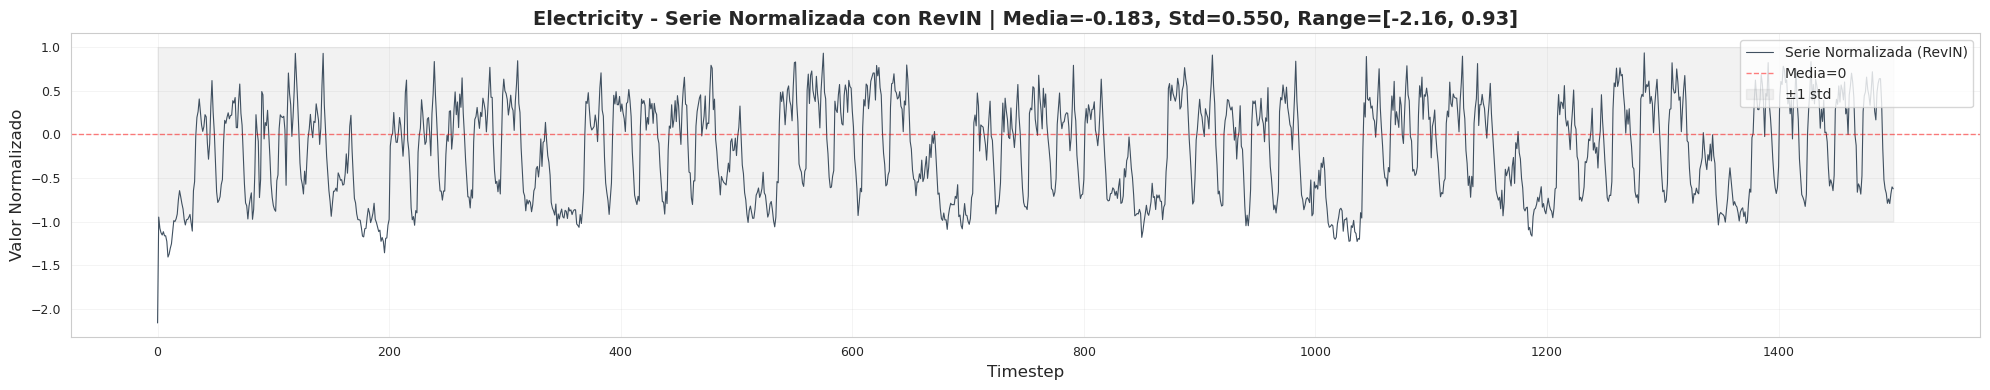

[ESTADÍSTICAS SERIE NORMALIZADA]
  Media: -0.183307 (debe estar cerca de 0)
  Desviación estándar: 0.549546 (debe estar cerca de 1)
  Min: -2.163, Max: 0.934
  Rango: 3.097


In [9]:
# Visualizar serie normalizada con RevIN
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(elec_series, linewidth=0.8, color='#2C3E50', alpha=0.9, label='Serie Normalizada (RevIN)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Media=0')
ax.fill_between(range(len(elec_series)), -1, 1, alpha=0.1, color='gray', label='±1 std')

# Calcular estadísticas
mean_val = elec_series.mean()
std_val = elec_series.std()
min_val = elec_series.min()
max_val = elec_series.max()

ax.set_title(f'Electricity - Serie Normalizada con RevIN | Media={mean_val:.3f}, Std={std_val:.3f}, Range=[{min_val:.2f}, {max_val:.2f}]',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Valor Normalizado', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[ESTADÍSTICAS SERIE NORMALIZADA]")
print(f"  Media: {mean_val:.6f} (debe estar cerca de 0)")
print(f"  Desviación estándar: {std_val:.6f} (debe estar cerca de 1)")
print(f"  Min: {min_val:.3f}, Max: {max_val:.3f}")
print(f"  Rango: {max_val - min_val:.3f}")

## Técnica 1: HMM - Estados Ocultos de Markov

**Descripción:**
- Entrena HMM con K=5 estados usando algoritmo Baum-Welch (EM)
- Cada estado k tiene distribución gaussiana N(μ_k, σ²_k)
- Algoritmo Viterbi encuentra secuencia óptima Q* = argmax P(Q|O,λ)
- Estados capturan regímenes temporales de la serie

**Interpretación:**
- Colores indican estado activo en cada timestep
- Líneas horizontales punteadas: medias μ_k de cada estado
- Cambios de color: transiciones entre regímenes
- Matriz A: probabilidades de transición P(j|i)

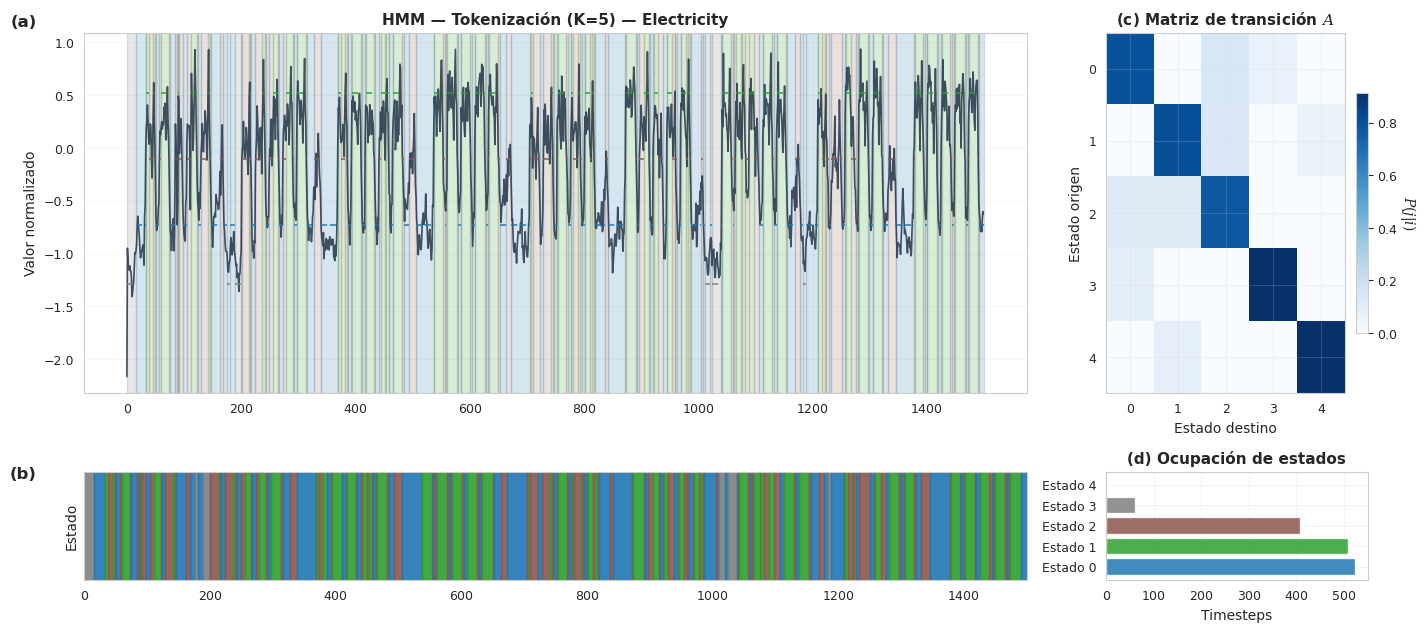

[ESTADÍSTICAS HMM]
  Número de estados (K): 5
  Estados únicos usados: 4
  Compression Ratio: 6.45
  Número de segmentos: 2854
  Duración promedio segmento: 6.45 timesteps
  Entropía de estados: 1.583 (max=1.609)

  Parámetros por estado:
    Estado 0: μ=-0.730, σ=0.194, freq=34.9% (524 timesteps)
    Estado 1: μ=0.516, σ=0.254, freq=33.9% (508 timesteps)
    Estado 2: μ=-0.104, σ=0.222, freq=27.2% (408 timesteps)
    Estado 3: μ=-1.289, σ=0.217, freq=4.0% (60 timesteps)
    Estado 4: μ=1.704, σ=0.767, freq=0.0% (0 timesteps)


In [10]:
import itertools
fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.6))
gs = fig.add_gridspec(3, 4, height_ratios=[2, 0.6, 1])
ax_series = fig.add_subplot(gs[0, :3])
ax_statebar = fig.add_subplot(gs[1, :3])
ax_trans = fig.add_subplot(gs[0, 3])
ax_occup = fig.add_subplot(gs[1, 3])

# Serie (panel principal)
ax_series.plot(elec_series, linewidth=1.2, color='#2C3E50', alpha=0.9, label='Serie')
ax_series.set_title(f'HMM — Tokenización (K={K_SELECTED}) — Electricity', fontsize=11, fontweight='bold')
ax_series.set_ylabel('Valor normalizado')
ax_series.grid(True, alpha=0.25)
ax_series.text(-0.05, 1.05, '(a)', transform=ax_series.transAxes,
               fontsize=12, fontweight='bold', va='top', ha='right')

# Contiguous segments (inicio, fin, estado)
segments = []
if len(elec_states_vis) > 0:
    start = 0
    curr = int(elec_states_vis[0])
    for i, s in enumerate(elec_states_vis):
        s = int(s)
        if s != curr:
            segments.append((start, i, curr))
            start = i; curr = s
    segments.append((start, len(elec_states_vis), curr))
else:
    segments = []

# Colores accesibles y consistentes
colors = plt.get_cmap('tab10')(np.linspace(0, 1, max(K_SELECTED, 1)))

# Dibujar spans por segmento y línea de media por estado (si está disponible)
for (s, e, state) in segments:
    c = colors[state % len(colors)]
    ax_series.axvspan(s, e, color=c, alpha=0.18)
    mu_k = elec_params.get('mu', [np.nan]*K_SELECTED)[state]
    ax_series.hlines(mu_k, s, e, colors=[c], linestyles='--', linewidth=1.2, alpha=0.9)

# Barra compacta de estados
for (s, e, state) in segments:
    c = colors[state % len(colors)]
    ax_statebar.axvspan(s, e, color=c, alpha=0.9)
ax_statebar.set_yticks([])
ax_statebar.set_ylabel('Estado')
ax_statebar.set_xlim(0, len(elec_series))
ax_statebar.grid(False)
ax_statebar.text(-0.05, 1.05, '(b)', transform=ax_statebar.transAxes,
                 fontsize=12, fontweight='bold', va='top', ha='right')

# Matriz de transición (derecha superior) — acceso seguro
A = elec_params.get('A', None)
if A is None:
    A = elec_params.get('trans_mat', None)
if A is None:
    A = hmm_elec.get('A', None)

if A is not None:
    im = ax_trans.imshow(np.array(A), aspect='auto', cmap='Blues')
    ax_trans.set_title('(c) Matriz de transición $A$', fontsize=11, fontweight='bold')
    ax_trans.set_xlabel('Estado destino')
    ax_trans.set_ylabel('Estado origen')
    cbar = plt.colorbar(im, ax=ax_trans, fraction=0.046, pad=0.04)
    cbar.set_label('$P(j|i)$', rotation=270, labelpad=15)
else:
    ax_trans.text(0.5, 0.5, 'A no disponible', ha='center', va='center', fontsize=10)
    ax_trans.text(-0.05, 1.05, '(c)', transform=ax_trans.transAxes,
                  fontsize=12, fontweight='bold', va='top', ha='right')

# Barra de ocupación (derecha inferior)
state_counts = [(elec_states_vis==k).sum() for k in range(K_SELECTED)]
ax_occup.barh(range(K_SELECTED), state_counts, color=colors[:K_SELECTED], alpha=0.85)
ax_occup.set_yticks(range(K_SELECTED))
ax_occup.set_yticklabels([f'Estado {k}' for k in range(K_SELECTED)])
ax_occup.set_xlabel('Timesteps')
ax_occup.set_title('(d) Ocupación de estados', fontsize=11, fontweight='bold')

# Ajuste y mostrar
plt.tight_layout()
plt.show()

print('[ESTADÍSTICAS HMM]')
print(f'  Número de estados (K): {K_SELECTED}')
print(f'  Estados únicos usados: {len(np.unique(elec_states_vis))}')
print(f"  Compression Ratio: {hmm_elec.get('compression_ratio', np.nan):.2f}")
print(f"  Número de segmentos: {hmm_elec.get('n_segments', np.sum(np.diff(np.concatenate([[elec_states_vis[0]], elec_states_vis])) != 0))}")
print(f"  Duración promedio segmento: {hmm_elec.get('avg_segment_duration', np.mean([e-s for s,e,_ in segments]) if segments else np.nan):.2f} timesteps")
print(f"  Entropía de estados: {hmm_elec.get('state_entropy', np.nan):.3f} (max={np.log(K_SELECTED):.3f})")

print('\n  Parámetros por estado:')
for k in range(K_SELECTED):
    count = int((elec_states_vis == k).sum())
    pct = (count / len(elec_states_vis) * 100) if len(elec_states_vis) > 0 else 0.0
    mu_k = elec_params.get('mu', [np.nan]*K_SELECTED)[k]
    sigma_k = elec_params.get('sigma', [np.nan]*K_SELECTED)[k]
    print(f'    Estado {k}: μ={mu_k:.3f}, σ={sigma_k:.3f}, freq={pct:.1f}% ({count} timesteps)')

## Técnica 2: SAX - Symbolic Aggregate approXimation

**Descripción:**
- Normaliza serie con z-score: (x - μ) / σ
- Divide espacio en N regiones equiprobables bajo N(0,1)
- Asigna símbolo alfabético a cada timestep según región
- Vocabulario de 8 símbolos: {a, b, c, d, e, f, g, h}

**Interpretación:**
- Líneas rojas horizontales: breakpoints gaussianos
- Puntos coloreados: símbolos discretos asignados
- Reduce serie continua a secuencia de caracteres

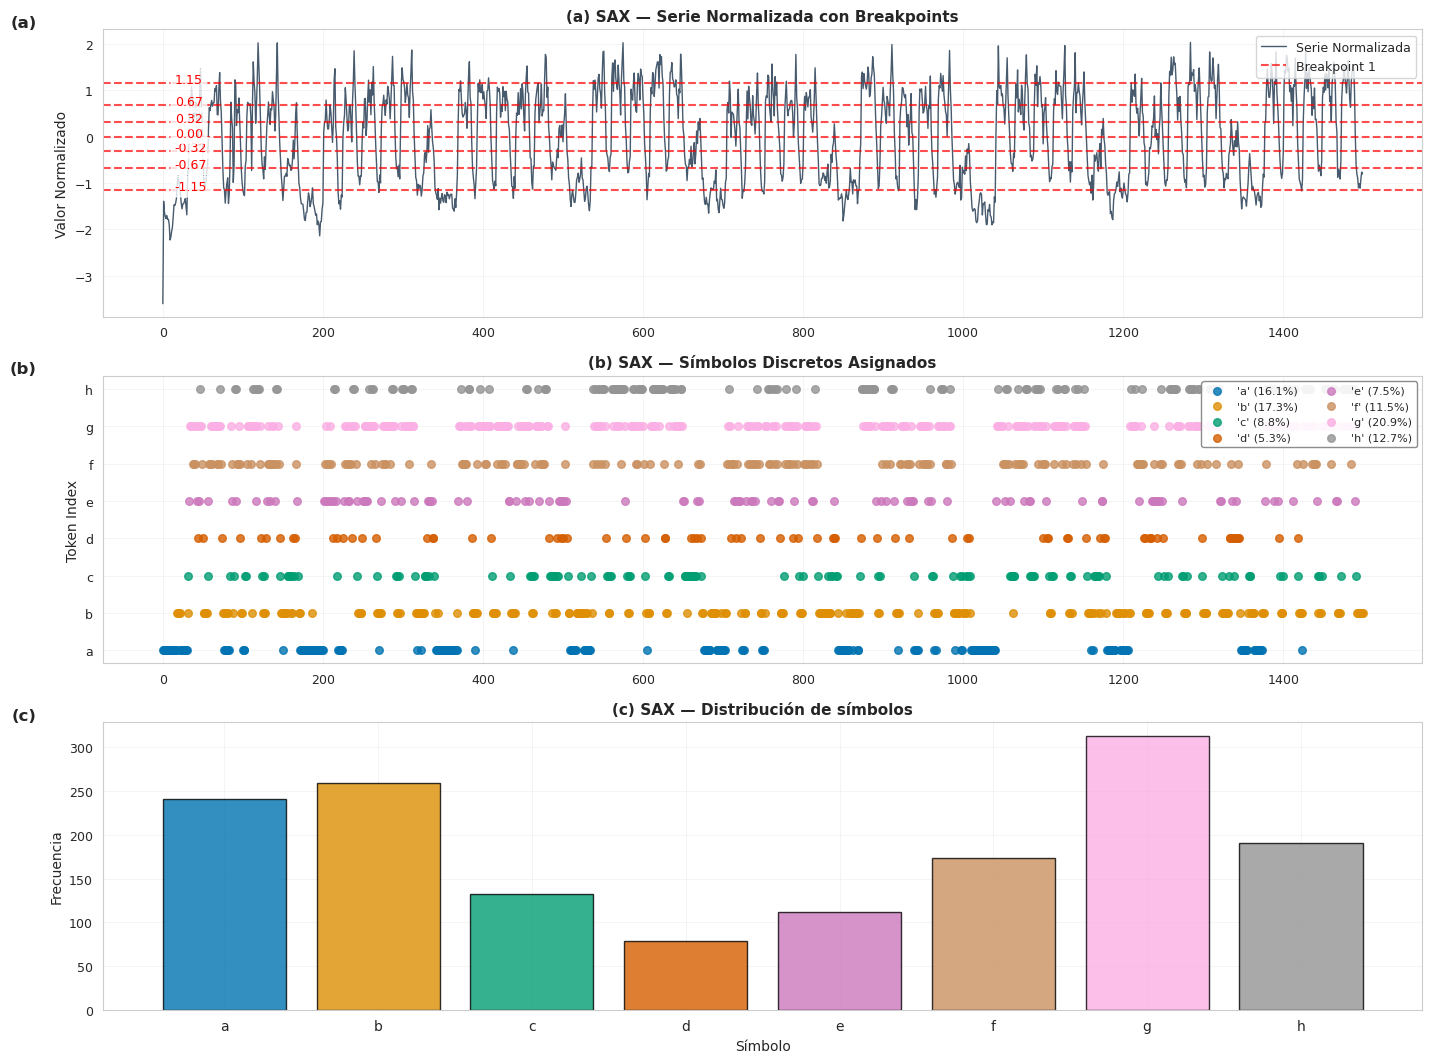

[ESTADÍSTICAS SAX]
  Vocabulary Size: 8
  Símbolos únicos usados: 8
  Num Tokens: 1500
  Compression Ratio: 1.0000 (sin compresión)


In [11]:
sax_viz = visualize_sax(elec_series, elec_sax['symbols'], elec_sax['tokens'], elec_sax['breakpoints'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*2))

# Panel 1: Serie normalizada con breakpoints
ax1.plot(sax_viz['normalized'], linewidth=1, color='#34495E', alpha=0.9, label='Serie Normalizada')
for i, bp in enumerate(elec_sax['breakpoints']):
    ax1.axhline(bp, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Breakpoint {i+1}' if i == 0 else '')
    ax1.text(len(elec_series)*0.01, bp, f'{bp:.2f}', fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_title('(a) SAX — Serie Normalizada con Breakpoints', fontsize=11, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 2: Símbolos discretos asignados
colors_sax = sns.color_palette('colorblind', n_colors=elec_sax['vocabulary_size'])
for sym_idx in range(elec_sax['vocabulary_size']):
    mask = elec_sax['tokens'] == sym_idx
    if mask.any():
        count = mask.sum()
        pct = count / len(elec_series) * 100
        ax2.scatter(np.where(mask)[0], elec_sax['tokens'][mask], color=colors_sax[sym_idx], s=30, alpha=0.8, label=f"'{elec_sax['alphabet'][sym_idx]}' ({pct:.1f}%)")

ax2.set_title('(b) SAX — Símbolos Discretos Asignados', fontsize=11, fontweight='bold')
ax2.set_ylabel('Token Index', fontsize=10)
ax2.set_yticks(range(elec_sax['vocabulary_size']))
ax2.set_yticklabels([elec_sax['alphabet'][i] for i in range(elec_sax['vocabulary_size'])])
ax2.legend(loc='upper right', ncol=2, fontsize=8, framealpha=0.9, edgecolor='gray')
ax2.grid(True, alpha=0.3)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 3: Distribución de símbolos
unique, counts = np.unique(elec_sax['symbols'], return_counts=True)
ax3.bar(range(len(unique)), counts, color=[colors_sax[elec_sax['alphabet'].index(s)] for s in unique], alpha=0.8, edgecolor='black')
ax3.set_xlabel('Símbolo'); ax3.set_ylabel('Frecuencia')
ax3.set_title('(c) SAX — Distribución de símbolos', fontsize=11, fontweight='bold')
ax3.set_xticks(range(len(unique)))
ax3.set_xticklabels(unique, fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.text(-0.05, 1.05, '(c)', transform=ax3.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

print('[ESTADÍSTICAS SAX]')
print(f"  Vocabulary Size: {elec_sax['vocabulary_size']}")
print(f"  Símbolos únicos usados: {len(np.unique(elec_sax['symbols']))}")
print(f"  Num Tokens: {elec_sax['num_tokens']}")
print(f"  Compression Ratio: {elec_sax['compression_ratio']:.4f} (sin compresión)")

## Técnica 3: LLMTime - Text-based Tokenization

**Descripción:**
- Convierte cada valor numérico a representación textual
- Base 10 decimal con 2 dígitos de precisión
- Separa dígitos con espacios: 23.45 → " 2 3 . 4 5"
- LLMs procesan serie como secuencia de caracteres

**Interpretación:**
- Longitud de token varía según magnitud del valor
- Valores grandes → tokens más largos
- Compression ratio < 1 (expansión, no compresión)

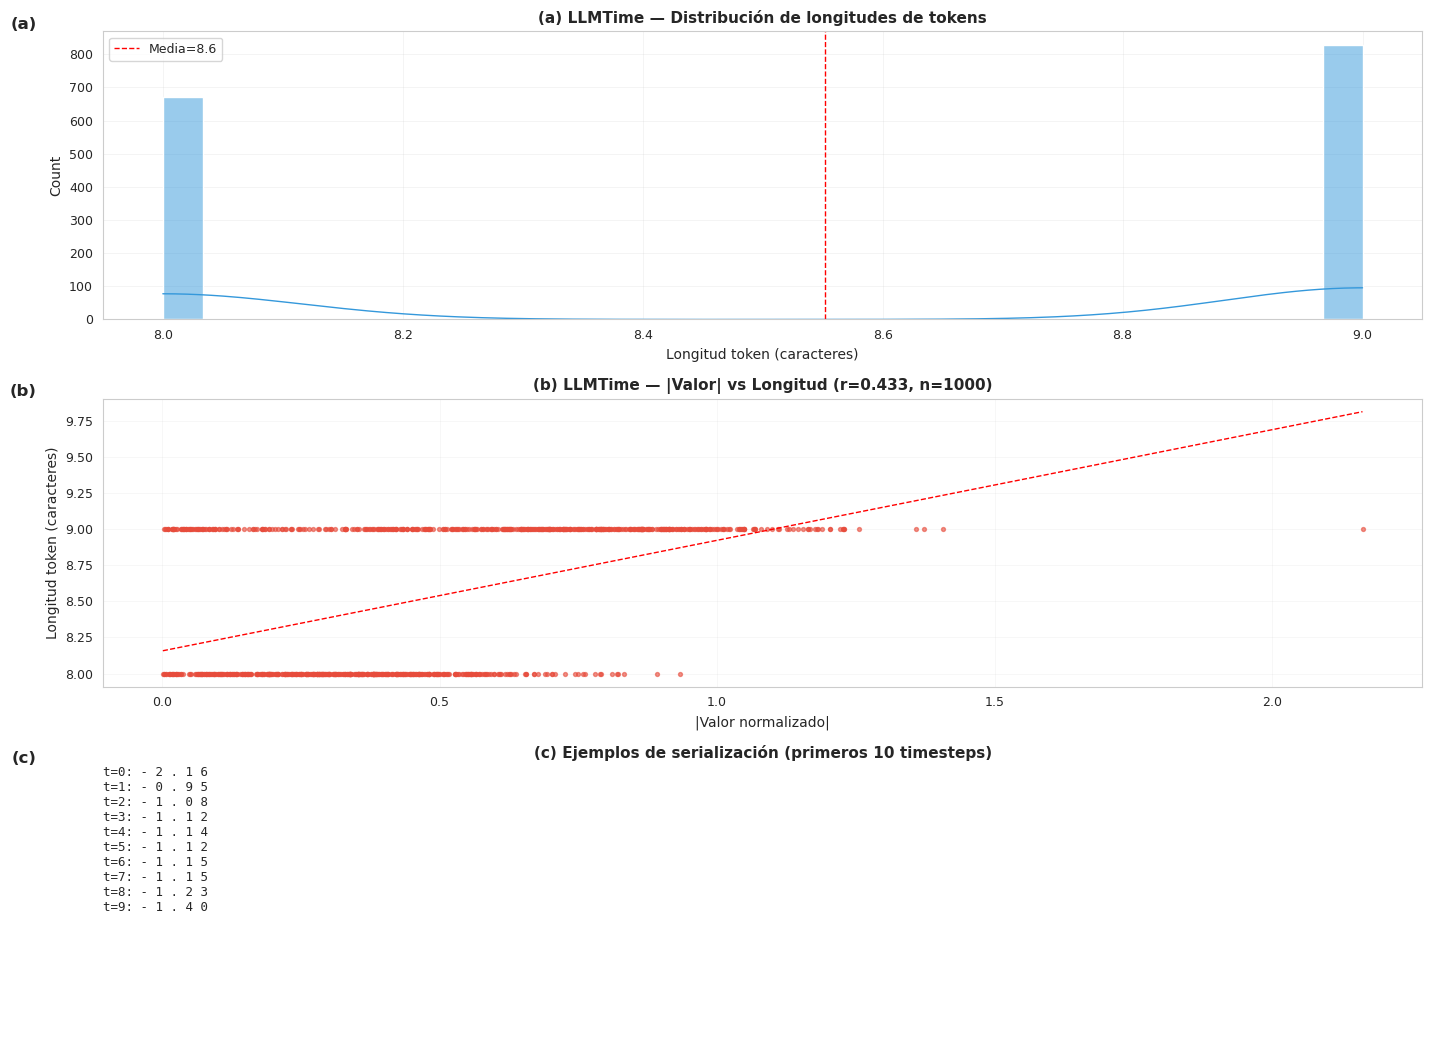

[ESTADÍSTICAS LLMTIME]
  Total caracteres: 12828
  Longitud media token: 8.55 caracteres
  Compression Ratio: 0.094781 (expansión, no compresión)
  Tamaño vocabulario: 13 (dígitos, signo, punto, separador)


In [12]:
text_viz = visualize_text_based(elec_series, elec_text['tokens_per_value'])
fig, (ax_hist, ax_scatter, ax_examples) = plt.subplots(3, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*2))

# Panel 1: Histograma + KDE de longitudes de tokens
sns.histplot(text_viz['token_lengths'], bins=30, kde=True, ax=ax_hist, color='#3498DB')
avg_len = text_viz.get('avg_token_length', np.mean(text_viz['token_lengths']) if len(text_viz['token_lengths'])>0 else 0)
ax_hist.axvline(avg_len, color='red', linestyle='--', label=f'Media={avg_len:.1f}')
ax_hist.set_title('(a) LLMTime — Distribución de longitudes de tokens', fontsize=11, fontweight='bold')
ax_hist.set_xlabel('Longitud token (caracteres)', fontsize=10)
ax_hist.legend(fontsize=9)
ax_hist.text(-0.05, 1.05, '(a)', transform=ax_hist.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 2: Scatter (submuestreo para evitar overplotting)
n = len(text_viz['token_lengths']); subsample = np.linspace(0, n-1, min(1000, n), dtype=int) if n>0 else []
abs_vals = np.abs(elec_series)[subsample]
lens = np.array(text_viz['token_lengths'])[subsample]
if len(abs_vals)>0:
    ax_scatter.scatter(abs_vals, lens, s=8, alpha=0.6, color='#E74C3C')
    z = np.polyfit(abs_vals, lens, 1) if len(abs_vals)>1 else (0,0)
    if len(abs_vals)>1:
        ax_scatter.plot(np.linspace(abs_vals.min(), abs_vals.max(), 100), np.poly1d(z)(np.linspace(abs_vals.min(), abs_vals.max(), 100)), 'r--', linewidth=1)
    corr = np.corrcoef(np.abs(elec_series), text_viz['token_lengths'])[0,1]
else:
    corr = np.nan
ax_scatter.set_title(f'(b) LLMTime — |Valor| vs Longitud (r={corr:.3f}, n={len(subsample)})', fontsize=11, fontweight='bold')
ax_scatter.set_xlabel('|Valor normalizado|', fontsize=10)
ax_scatter.set_ylabel('Longitud token (caracteres)', fontsize=10)
ax_scatter.grid(True, alpha=0.2)
ax_scatter.text(-0.05, 1.05, '(b)', transform=ax_scatter.transAxes,
               fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 3: Ejemplos (primeros N serializados)
example_texts = elec_text.get('tokens_per_value', [])[:10]
ax_examples.spines['top'].set_visible(False)
ax_examples.spines['right'].set_visible(False)
ax_examples.spines['left'].set_visible(False)
ax_examples.spines['bottom'].set_visible(False)
ax_examples.set_xticks([])
ax_examples.set_yticks([])
example_str = '\n'.join([f't={i}: {example_texts[i]}' for i in range(len(example_texts))]) if example_texts else 'No hay ejemplos disponibles'
ax_examples.text(0, 1, example_str, va='top', fontsize=9, family='monospace')
ax_examples.set_title('(c) Ejemplos de serialización (primeros 10 timesteps)', fontsize=11, fontweight='bold')
ax_examples.text(-0.05, 1.05, '(c)', transform=ax_examples.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

print('[ESTADÍSTICAS LLMTIME]')
print(f"  Total caracteres: {text_viz.get('total_characters', 0)}")
print(f"  Longitud media token: {text_viz.get('avg_token_length', 0):.2f} caracteres")
print(f"  Compression Ratio: {elec_text.get('compression_ratio', 0):.6f} (expansión, no compresión)")
print(f"  Tamaño vocabulario: {elec_text.get('vocabulary_size', 0)} (dígitos, signo, punto, separador)")

## Técnica 4: PatchTST - Patch-based Tokenization

**Descripción:**
- Divide serie en patches de longitud fija (16 timesteps)
- Sin solapamiento (stride=16)
- Cada patch es un token multidimensional ∈ R^16
- Reduce complejidad de O(L²) a O((L/P)²) en Transformers

**Interpretación:**
- Líneas rojas verticales: boundaries entre patches
- Heatmap: cada columna es un patch, colores = valores
- Varianza por patch: indica variabilidad local

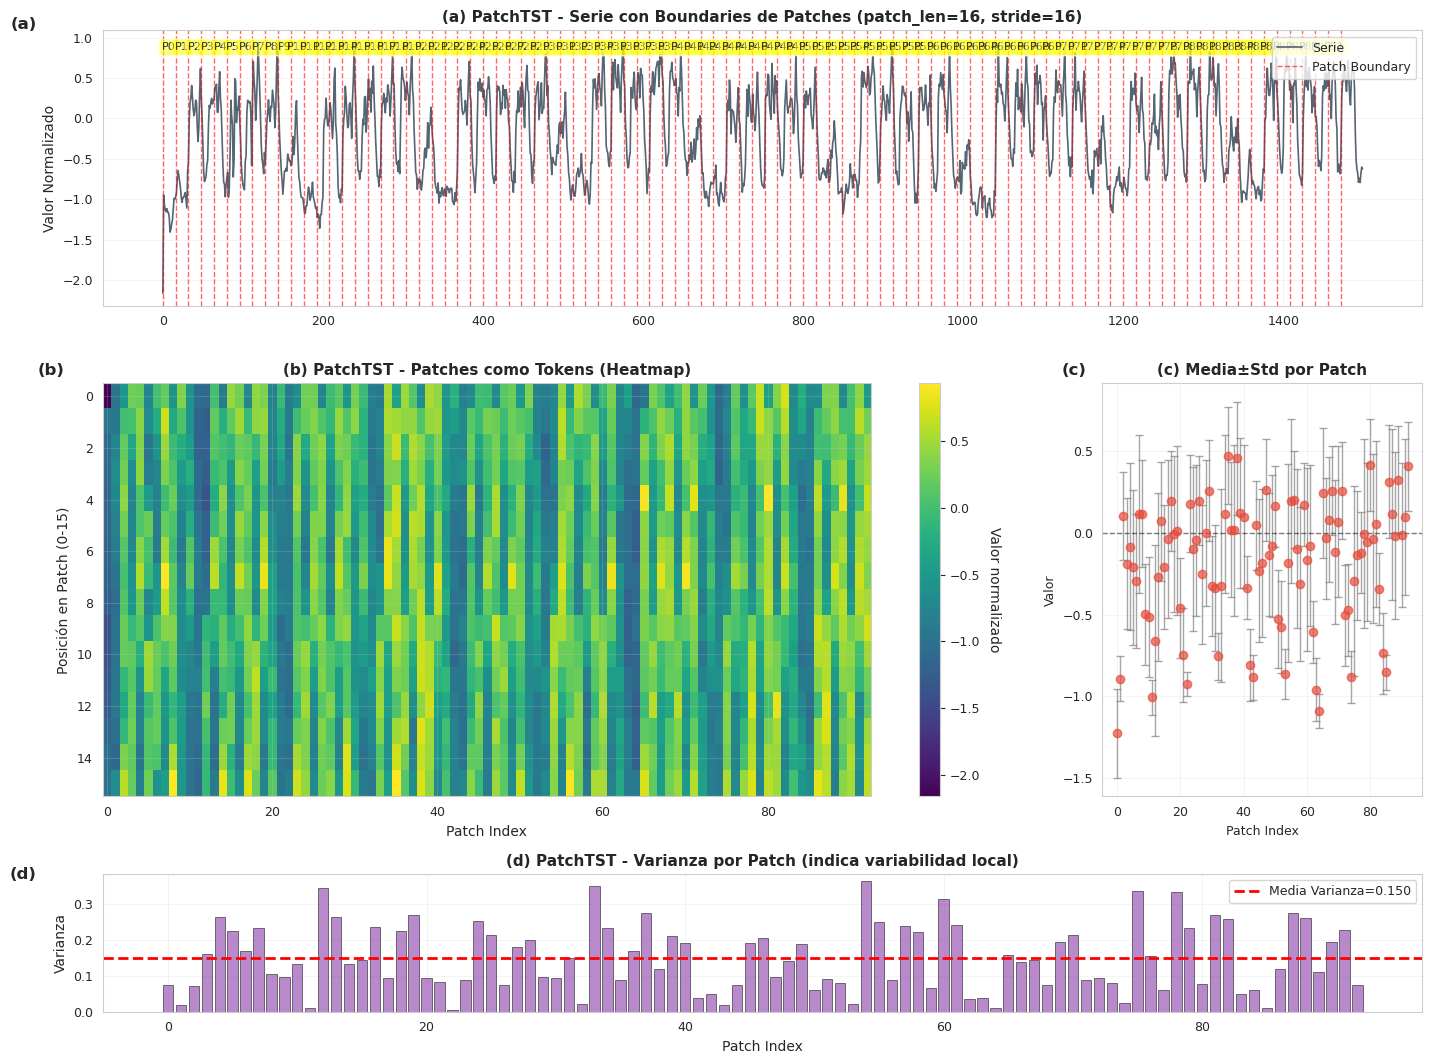

[ESTADÍSTICAS PATCHTST]
  Patch Length: 16 timesteps
  Stride: 16 (sin solapamiento)
  Num Patches: 93
  Compression Ratio: 16.13
  Timesteps cubiertos: 1488
  Timesteps descartados: 12

  Estadísticas de patches:
    Media de varianzas: 0.1495
    Std de varianzas: 0.0925
    Patch más variable: índice 54 (var=0.3650)
    Patch menos variable: índice 22 (var=0.0054)


In [13]:
patch_viz = visualize_patches(elec_series, elec_patch_array, 16, 16)

vmin = elec_patch_array.min()
vmax = elec_patch_array.max()

fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*2))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 3, 1], width_ratios=[3, 1])

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, :])

# Panel 1: Serie con boundaries
ax1.plot(elec_series, linewidth=1.2, color='#2C3E50', alpha=0.8, label='Serie')
for i, pos in enumerate(patch_viz['positions']):
    ax1.axvline(pos, color='red', linestyle='--', linewidth=1, alpha=0.6,
                label='Patch Boundary' if i == 0 else '')
    if i < len(patch_viz['positions']) - 1:
        mid_pos = pos + 8
        ax1.text(mid_pos, elec_series.max()*0.9, f'P{i}', ha='center', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax1.set_title(f'(a) PatchTST - Serie con Boundaries de Patches (patch_len=16, stride=16)',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 2: Heatmap de patches
im = ax2.imshow(elec_patch_array.T, aspect='auto', cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
ax2.set_title('(b) PatchTST - Patches como Tokens (Heatmap)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Patch Index', fontsize=10)
ax2.set_ylabel('Posición en Patch (0-15)', fontsize=10)
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor normalizado', rotation=270, labelpad=15)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 3: Estadísticas por patch
patch_means = elec_patch_array.mean(axis=1)
patch_stds = elec_patch_array.std(axis=1)
ax3.errorbar(range(len(patch_means)), patch_means, yerr=patch_stds,
             fmt='o', color='#E74C3C', ecolor='gray', alpha=0.7, capsize=3)
ax3.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_title('(c) Media±Std por Patch', fontsize=11, fontweight='bold')
ax3.set_xlabel('Patch Index', fontsize=9)
ax3.set_ylabel('Valor', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.text(-0.05, 1.05, '(c)', transform=ax3.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 4: Distribución de varianzas
patch_vars = elec_patch_array.var(axis=1)
ax4.bar(range(len(patch_vars)), patch_vars, color='#9B59B6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axhline(patch_vars.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Media Varianza={patch_vars.mean():.3f}')
ax4.set_xlabel('Patch Index', fontsize=10)
ax4.set_ylabel('Varianza', fontsize=10)
ax4.set_title('(d) PatchTST - Varianza por Patch (indica variabilidad local)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')
ax4.text(-0.05, 1.05, '(d)', transform=ax4.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

print("[ESTADÍSTICAS PATCHTST]")
print(f"  Patch Length: 16 timesteps")
print(f"  Stride: 16 (sin solapamiento)")
print(f"  Num Patches: {patch_viz['num_patches']}")
print(f"  Compression Ratio: {patch_viz['compression_ratio']:.2f}")
print(f"  Timesteps cubiertos: {patch_viz['num_patches'] * 16}")
print(f"  Timesteps descartados: {len(elec_series) - patch_viz['num_patches'] * 16}")
print(f"\n  Estadísticas de patches:")
print(f"    Media de varianzas: {patch_vars.mean():.4f}")
print(f"    Std de varianzas: {patch_vars.std():.4f}")
print(f"    Patch más variable: índice {patch_vars.argmax()} (var={patch_vars.max():.4f})")
print(f"    Patch menos variable: índice {patch_vars.argmin()} (var={patch_vars.min():.4f})")

## Técnica 5: Autoformer - Trend-Seasonal Decomposition

**Descripción:**
- Usa promedio móvil (kernel=25) para extraer tendencia
- Seasonal = Serie original - Trend
- Genera 2 tokens: (trend, seasonal)
- Cada componente se modela independientemente

**Interpretación:**
- Trend: componente de baja frecuencia (suave)
- Seasonal: componente de alta frecuencia (oscilaciones)
- Reconstrucción = Trend + Seasonal debe ≈ Serie original

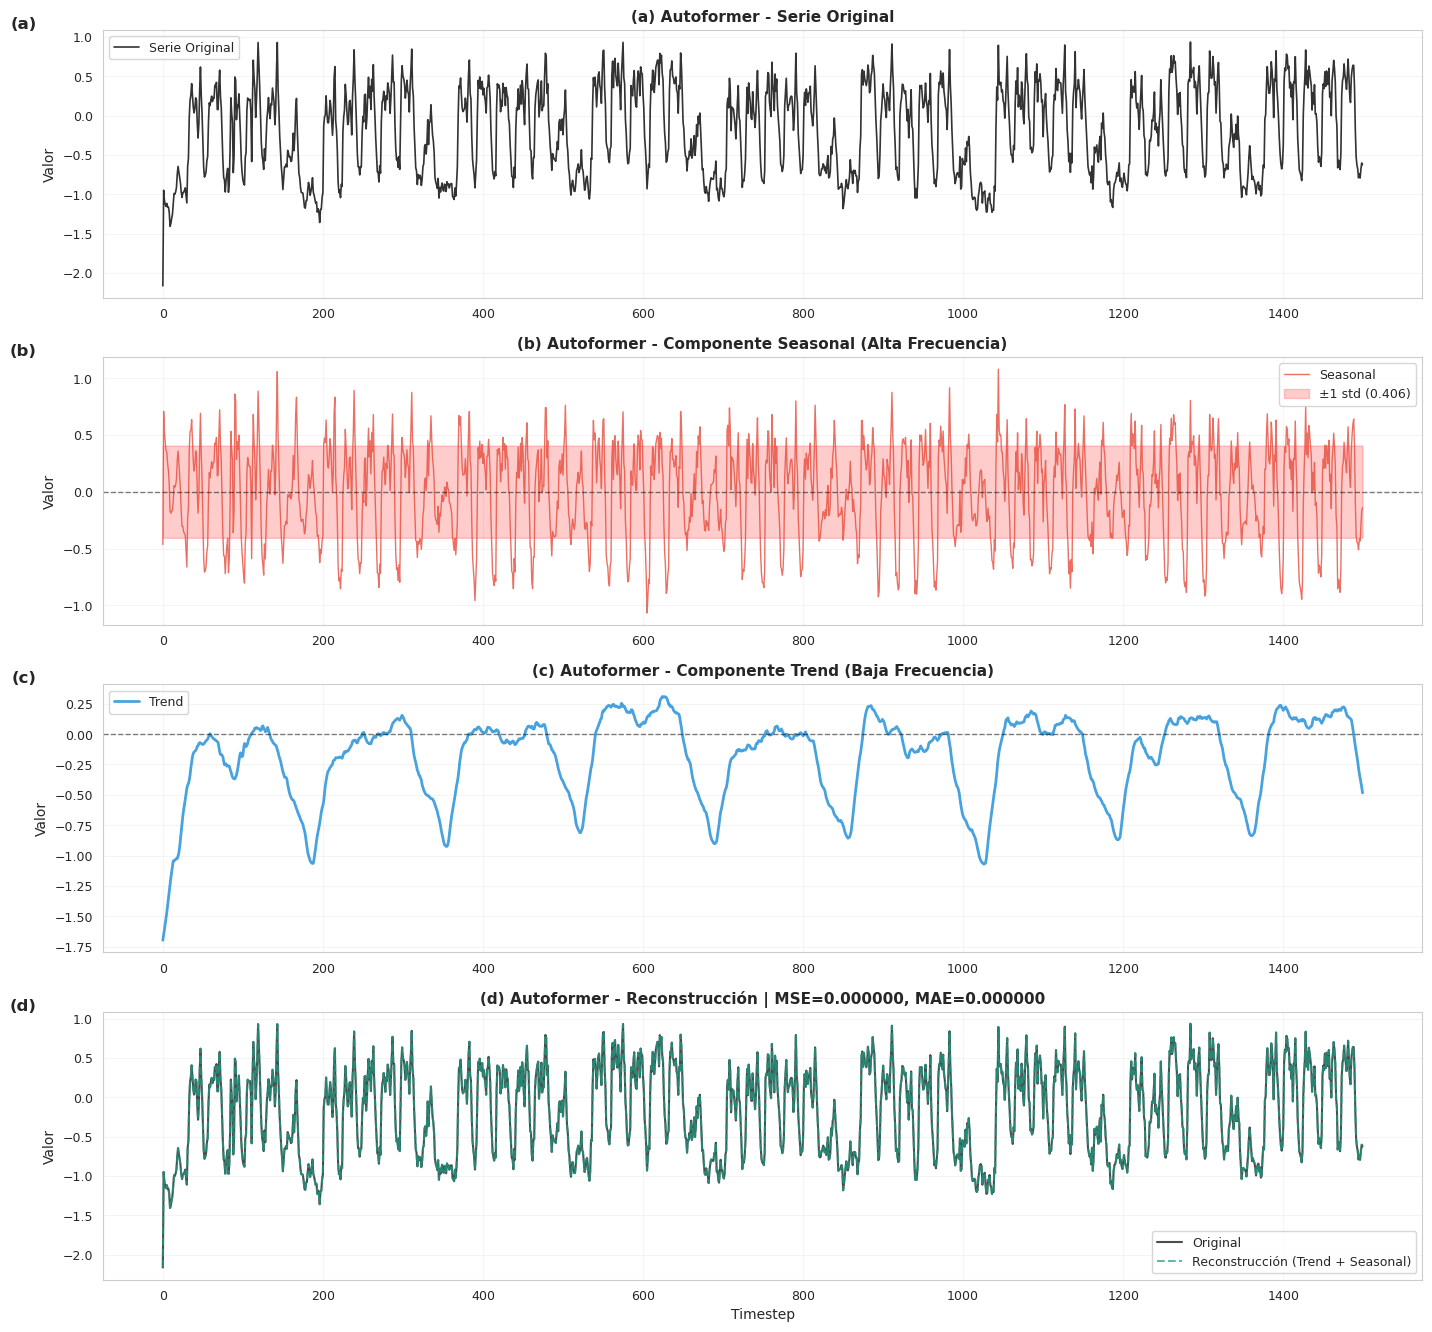

[ESTADÍSTICAS AUTOFORMER]
  Num Tokens: 2 (trend + seasonal)
  Compression Ratio: 750.00
  Kernel Size (promedio móvil): 25 timesteps

  Componente Seasonal:
    Media: 0.001841 (debe ser ~0)
    Std: 0.4057
    Rango: [-1.068, 1.078]

  Componente Trend:
    Media: -0.185148
    Std: 0.3455
    Rango: [-1.698, 0.310]

  Calidad Reconstrucción:
    MSE: 0.00000000
    MAE: 0.00000000
    Max Error Absoluto: 0.00000006


In [14]:
decomp_viz = visualize_decomposition(elec_decomp)

fig, axes = plt.subplots(4, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*2.5))

# Panel 1: Serie original
axes[0].plot(elec_series, linewidth=1.2, color='black', alpha=0.8, label='Serie Original')
axes[0].set_title('(a) Autoformer - Serie Original', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].text(-0.05, 1.05, '(a)', transform=axes[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 2: Componente Seasonal (alta frecuencia)
axes[1].plot(elec_decomp['seasonal'], linewidth=1, color='#E74C3C', alpha=0.8, label='Seasonal')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
seasonal_std = elec_decomp['seasonal'].std()
axes[1].fill_between(range(len(elec_decomp['seasonal'])), -seasonal_std, seasonal_std,
                     alpha=0.2, color='red', label=f'±1 std ({seasonal_std:.3f})')
axes[1].set_title('(b) Autoformer - Componente Seasonal (Alta Frecuencia)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Valor', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].text(-0.05, 1.05, '(b)', transform=axes[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 3: Componente Trend (baja frecuencia)
axes[2].plot(elec_decomp['trend'], linewidth=2, color='#3498DB', alpha=0.9, label='Trend')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_title('(c) Autoformer - Componente Trend (Baja Frecuencia)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Valor', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].text(-0.05, 1.05, '(c)', transform=axes[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 4: Reconstrucción vs Original
axes[3].plot(elec_series, linewidth=1.5, color='black', alpha=0.7, label='Original', linestyle='-')
axes[3].plot(decomp_viz['reconstruction'], linewidth=1.5, color='#16A085', alpha=0.7,
            label='Reconstrucción (Trend + Seasonal)', linestyle='--')
error = np.abs(elec_series - decomp_viz['reconstruction'])
mse = (error ** 2).mean()
mae = error.mean()
axes[3].set_title(f'(d) Autoformer - Reconstrucción | MSE={mse:.6f}, MAE={mae:.6f}',
                 fontsize=11, fontweight='bold')
axes[3].set_xlabel('Timestep', fontsize=10)
axes[3].set_ylabel('Valor', fontsize=10)
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)
axes[3].text(-0.05, 1.05, '(d)', transform=axes[3].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

# Análisis espectral
from scipy.fft import fft, fftfreq

print("[ESTADÍSTICAS AUTOFORMER]")
print(f"  Num Tokens: {elec_decomp['num_tokens']} (trend + seasonal)")
print(f"  Compression Ratio: {elec_decomp['compression_ratio']:.2f}")
print(f"  Kernel Size (promedio móvil): 25 timesteps")
print(f"\n  Componente Seasonal:")
print(f"    Media: {elec_decomp['seasonal'].mean():.6f} (debe ser ~0)")
print(f"    Std: {elec_decomp['seasonal'].std():.4f}")
print(f"    Rango: [{elec_decomp['seasonal'].min():.3f}, {elec_decomp['seasonal'].max():.3f}]")
print(f"\n  Componente Trend:")
print(f"    Media: {elec_decomp['trend'].mean():.6f}")
print(f"    Std: {elec_decomp['trend'].std():.4f}")
print(f"    Rango: [{elec_decomp['trend'].min():.3f}, {elec_decomp['trend'].max():.3f}]")
print(f"\n  Calidad Reconstrucción:")
print(f"    MSE: {mse:.8f}")
print(f"    MAE: {mae:.8f}")
print(f"    Max Error Absoluto: {error.max():.8f}")

## Técnica 6: MOMENT - Masked Patch Pre-training

**Descripción:**
- Segmenta en patches como PatchTST
- Enmascara 30% de patches aleatoriamente
- Modelo aprende a reconstruir patches enmascarados
- Pre-training self-supervised para foundation model

**Interpretación:**
- Regiones rojas: patches enmascarados (ocultos al modelo)
- Regiones azules: patches visibles (observados)
- Modelo debe predecir valores en regiones enmascaradas

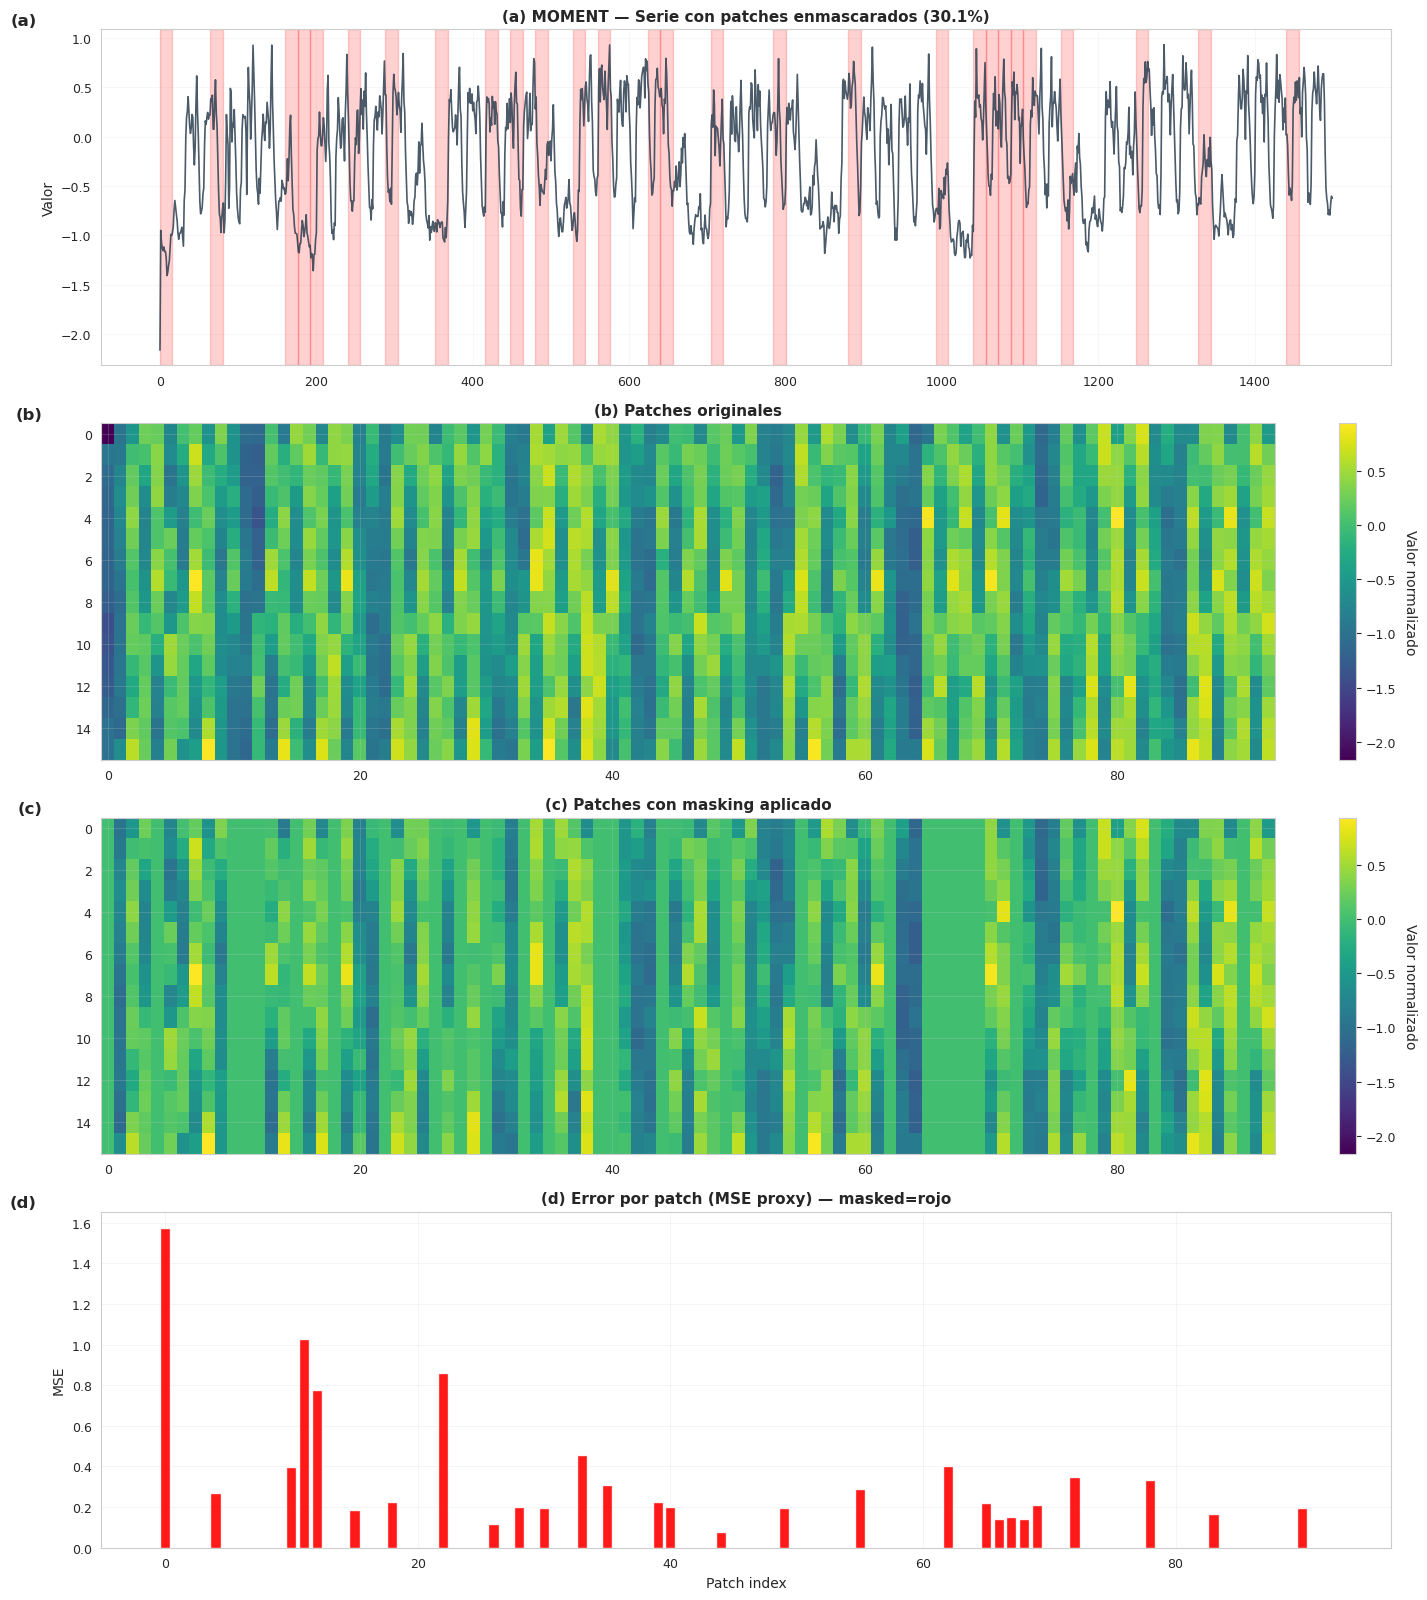

[ESTADÍSTICAS MOMENT]
  Patch Length: 16 timesteps
  Num Patches: 93
  Num Masked: 28 (indices: [0, 4, 10, 11, 12, 15, 18, 22, 26, 28, 30, 33, 35, 39, 40, 44, 49, 55, 62, 65, 66, 67, 68, 69, 72, 78, 83, 90])
  Mask Ratio: 30.1%
  Compression Ratio: 16.13


In [15]:
found_viz = visualize_foundation(elec_series, elec_foundation['patches'],
                                  elec_foundation['mask'], 16, 16)

# compute per-patch reconstruction error (if masked patches are zeroed)
patches = elec_foundation['patches']
masked = elec_foundation['mask']
masked_patches = found_viz['masked_patches']
patch_errors = np.mean((patches - masked_patches)**2, axis=1)

fig, axes = plt.subplots(4, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*3))

# Panel 1: serie with masked spans
axes[0].plot(elec_series, linewidth=1.2, color='#2C3E50', alpha=0.85, label='Serie')
for i, (pos, is_mask) in enumerate(zip(found_viz['patch_positions'], masked)):
    if is_mask:
        axes[0].axvspan(pos, pos+16, color='red', alpha=0.18)

axes[0].set_title(f'(a) MOMENT — Serie con patches enmascarados ({elec_foundation["mask_ratio_actual"]*100:.1f}%)',
                 fontsize=11, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=10)
axes[0].grid(True, alpha=0.2)
axes[0].text(-0.05, 1.05, '(a)', transform=axes[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 2: heatmap of patches (consistent vmin/vmax)
vmin = patches.min()
vmax = patches.max()
im1 = axes[1].imshow(patches.T, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('(b) Patches originales', fontsize=11, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.04)
cbar1.set_label('Valor normalizado', rotation=270, labelpad=15)
axes[1].text(-0.05, 1.05, '(b)', transform=axes[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 3: masked patches visualization
im2 = axes[2].imshow(masked_patches.T, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[2].set_title('(c) Patches con masking aplicado', fontsize=11, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[2], fraction=0.04)
cbar2.set_label('Valor normalizado', rotation=270, labelpad=15)
axes[2].text(-0.05, 1.05, '(c)', transform=axes[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel 4: per-patch MSE (error proxy) — highlights masked patches
axes[3].bar(range(len(patch_errors)), patch_errors,
           color=['red' if m else '#3498DB' for m in masked], alpha=0.9)
axes[3].set_title('(d) Error por patch (MSE proxy) — masked=rojo',
                 fontsize=11, fontweight='bold')
axes[3].set_xlabel('Patch index', fontsize=10)
axes[3].set_ylabel('MSE', fontsize=10)
axes[3].text(-0.05, 1.05, '(d)', transform=axes[3].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

print('[ESTADÍSTICAS MOMENT]')
print(f'  Patch Length: 16 timesteps')
print(f'  Num Patches: {elec_foundation["num_patches"]}')
print(f'  Num Masked: {elec_foundation["num_masked"]} (indices: {np.where(masked)[0].tolist()})')
print(f'  Mask Ratio: {elec_foundation["mask_ratio_actual"]*100:.1f}%')
print(f'  Compression Ratio: {elec_foundation["compression_ratio"]:.2f}')

In [16]:
print("\n" + "-"*140)
print("RESUMEN FINAL - COMPARACIÓN DE TÉCNICAS DE TOKENIZACIÓN")
print("-"*140)
print(table_combined.to_string(index=False))
print("-"*140)

print("\n[OBSERVACIONES CLAVE]")
print("  1. HMM: Vocabulary Size K=5 estados, genera segmentos mediante cambios de régimen")
print("  2. SAX: Vocabulary Size 8 símbolos, sin compresión (1:1), discretización interpretable")
print("  3. LLMTime: Vocabulary Size 13 caracteres, expansión de datos (CR < 1), permite uso de LLMs")
print("  4. PatchTST: Vocabulary continuo, compresión moderada (~16), reduce complejidad cuadrática")
print("  5. Autoformer: Vocabulary 2 componentes, máxima compresión (750)")
print("  6. MOMENT: Similar a PatchTST, enfoque en pre-training con masking")

print("\n[INTERPRETACIÓN HMM]")
print("  - Vocabulary Size = K = 5 estados ocultos (regímenes)")
print("  - Num Tokens (Segmentos) = número de cambios de estado en secuencia Viterbi")
print("  - Compression Ratio = serie_len / num_segmentos")
print("  - A MAYOR CR, MEJOR compresión (menos tokens necesarios)")

print("\n[OK] Comparación completada exitosamente")


--------------------------------------------------------------------------------------------------------------------------------------------
RESUMEN FINAL - COMPARACIÓN DE TÉCNICAS DE TOKENIZACIÓN
--------------------------------------------------------------------------------------------------------------------------------------------
      Técnica  Num Tokens (Segmentos)  Compression Ratio Vocabulary Size           Tipo                 Paper     Dataset  Serie Length
HMM (Viterbi)                     223           6.726457               5 Probabilístico    Tesis RITMO (2025) Electricity          1500
          SAX                    1500           1.000000               8       Discreto     Lin et al. (2007) Electricity          1500
      LLMTime                   15826           0.094781              13        Textual  Gruver et al. (2023) Electricity          1500
     PatchTST                      93          16.129032        Continuo   Segmentación     Nie et al. (2023) Electri